<a href="https://colab.research.google.com/github/AafreenZehra/AafreenPortfolio/blob/main/Web.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install nltk scikit-learn seaborn


In [2]:
import pandas as pd
import numpy as np
import nltk
import string
import re
import seaborn as sns
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [3]:
df = pd.read_csv("Wom.csv")

df.head()

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [4]:
df = df.dropna(subset=['Review Text'])

df.shape

(22641, 11)

In [5]:
doc1 = " ".join(df[df['Rating'] >= 4]['Review Text'].astype(str))
doc2 = " ".join(df[df['Rating'] == 3]['Review Text'].astype(str))
doc3 = " ".join(df[df['Rating'] <= 2]['Review Text'].astype(str))

documents = [doc1, doc2, doc3]

print("Documents created successfully!")

Documents created successfully!


In [6]:
stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = text.lower()                              # Lowercase
    text = re.sub(r'\d+', '', text)                  # Remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation))  # Remove punctuation
    tokens = text.split()                            # Tokenization
    tokens = [word for word in tokens if word not in stop_words]  # Stopword removal
    return " ".join(tokens)

documents = [preprocess(doc) for doc in documents]

print("Preprocessing completed!")

Preprocessing completed!


In [7]:
# ===============================
# TEXT PREPROCESSING
# ===============================

stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = text.lower()                              # 1. Lowercase
    text = re.sub(r'\d+', '', text)                  # 2. Remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation))  # 3. Remove punctuation
    tokens = text.split()                            # 4. Tokenization
    tokens = [word for word in tokens if word not in stop_words]  # 5. Stopword removal
    return " ".join(tokens)

# Apply preprocessing
documents = [preprocess(doc) for doc in documents]

print("Preprocessing completed!\n")

# ✅ SHOW SAMPLE OUTPUT AS PROOF
for i, doc in enumerate(documents):
    print(f"\n--- Preprocessed Document {i+1} (First 500 characters) ---\n")
    print(doc[:500])

Preprocessing completed!


--- Preprocessed Document 1 (First 500 characters) ---

absolutely wonderful silky sexy comfortable love dress sooo pretty happened find store im glad bc never would ordered online bc petite bought petite love length hits little knee would definitely true midi someone truly petite love love love jumpsuit fun flirty fabulous every time wear get nothing great compliments shirt flattering due adjustable front tie perfect length wear leggings sleeveless pairs well cardigan love shirt aded basket hte last mintue see would look like person store pick went 

--- Preprocessed Document 2 (First 500 characters) ---

high hopes dress really wanted work initially ordered petite small usual size found outrageously small small fact could zip reordered petite medium ok overall top half comfortable fit nicely bottom half tight layer several somewhat cheap net layers imo major design flaw net layer sewn directly zipper c dress runs small esp zipper area runs ordered sp typica

In [8]:
cv = CountVectorizer()
tf_matrix = cv.fit_transform(documents)

tf_df = pd.DataFrame(tf_matrix.toarray(), columns=cv.get_feature_names_out())

tf_df.head()

,aa,aaaaaaamazing,aaaaandidontwanttopayforshipping,aaaaannnnnnd,aaaahmazing,aaaahs,aaahed,aame,ab,abbey,...,zippie,zipping,zips,zombie,zone,zoolanders,zoom,zooming,zuma,ã¼ber
0,17,1,1,0,1,1,0,1,10,2,...,1,14,15,0,7,0,4,1,1,1
1,1,0,0,1,0,0,1,0,1,0,...,0,0,2,0,1,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,1,0,1,0,1,3,0,0,0


In [9]:
tfidf = TfidfVectorizer(use_idf=True)
tfidf_matrix = tfidf.fit_transform(documents)

idf_values = dict(zip(tfidf.get_feature_names_out(), tfidf.idf_))
idf_df = pd.DataFrame(idf_values.items(), columns=["Word", "IDF Value"])

idf_df.head()

,Word,IDF Value
0,aa,1.000000
1,aaaaaaamazing,1.693147
2,aaaaandidontwanttopayforshipping,1.693147
3,aaaaannnnnnd,1.693147
4,aaaahmazing,1.693147


In [10]:
cosine_sim = cosine_similarity(tfidf_matrix)

print("Cosine Similarity Matrix:")
print(cosine_sim)

Cosine Similarity Matrix:
[[1.         0.91997237 0.87579163]
 [0.91997237 1.         0.97778677]
 [0.87579163 0.97778677 1.        ]]


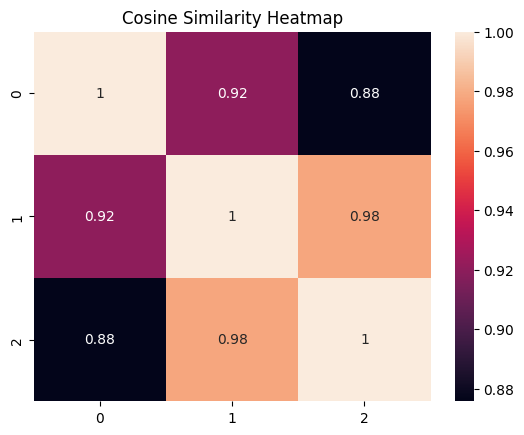

In [11]:
plt.figure()
sns.heatmap(cosine_sim, annot=True)
plt.title("Cosine Similarity Heatmap")
plt.show()

In [12]:
def jaccard_similarity(doc1, doc2):
    set1 = set(doc1.split())
    set2 = set(doc2.split())
    return len(set1.intersection(set2)) / len(set1.union(set2))

jaccard_matrix = np.zeros((3,3))

for i in range(3):
    for j in range(3):
        jaccard_matrix[i][j] = jaccard_similarity(documents[i], documents[j])

print("Jaccard Similarity Matrix:")
print(jaccard_matrix)

Jaccard Similarity Matrix:
[[1.         0.28088695 0.26090812]
 [0.28088695 1.         0.40430258]
 [0.26090812 0.40430258 1.        ]]


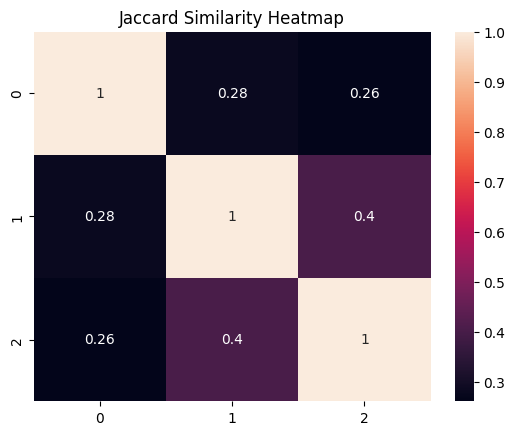

In [13]:
plt.figure()
sns.heatmap(jaccard_matrix, annot=True)
plt.title("Jaccard Similarity Heatmap")
plt.show()